# Laboratorio 4 — Simulación de eventos discretos
## 5.1 Sistema de línea de espera con un servidor (G/G/1)

Implementación basada en el notebook del curso *Sistema de línea de espera con un servidor - G/G/1.ipynb*
(Sec. 5.5.1 de Rios08). Se conserva la lógica de sucesos (`Llegada`, `Servidor`, lista de sucesos `TSuc`),
pero se reemplazan los dos generadores congruenciales del ejemplo por el generador congruencial mixto
validado en los laboratorios anteriores (GLC, $m=2^{48}$), y se encapsula todo en una función para poder
repetir la simulación.

**Escenario A:** $T=40$, llegadas $\sim$ Exp($\lambda=5$), servicio $\sim$ Exp($\lambda=3$).

**Escenario B:** $T=40$, llegadas $\sim$ Exp($\lambda=1$), servicio $\sim$ N($\mu=2,\sigma=1$) truncada en 0.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Generador congruencial mixto (Laboratorio 2) ----------------
A, C, M = 25214903917, 11, 2**48

class GLC:
    def __init__(self, X0, a=A, c=C, m=M):
        self.X, self.a, self.c, self.m = X0, a, c, m
        self.consumidos = 0
    def uniforme(self):
        self.X = (self.a * self.X + self.c) % self.m
        self.consumidos += 1
        return self.X / self.m

# ---------------- Generadores de variables aleatorias (Laboratorio 3) ----------------
def exponencial(g, lam):
    """Transformada inversa; lam es la TASA (mismo convenio que el notebook G/G/1 del curso)."""
    return -math.log(1 - g.uniforme()) / lam

_normal_cache = {}
def normal_polar(g, mu=0.0, sigma=1.0):
    """Método polar de Marsaglia; guarda la segunda normal del par para la siguiente llamada."""
    if g in _normal_cache:
        z = _normal_cache.pop(g)
    else:
        while True:
            v1, v2 = 2 * g.uniforme() - 1, 2 * g.uniforme() - 1
            s = v1 * v1 + v2 * v2
            if 0 < s <= 1:
                k = math.sqrt(-2 * math.log(s) / s)
                z, _normal_cache[g] = v1 * k, v2 * k
                break
    return mu + sigma * z

def normal_truncada(g, mu, sigma):
    """Normal truncada en cero, como exige la guía (valores negativos -> 0)."""
    return max(0.0, normal_polar(g, mu, sigma))

### Modelo G/G/1
La función `simular_gg1` recibe el horizonte $T$ y dos generadores (`genX` tiempos entre llegadas,
`genY` tiempos de servicio) y devuelve las cinco medidas de desempeño de la guía más las trayectorias
para graficar.

In [2]:
def simular_gg1(T, genX, genY, M=99999.0):
    # Estado y contadores (misma notación que Rios08 / notebook del curso)
    est = dict(t=0.0, n=0, NLL=0, NS=0)
    TSuc = {"tLL": M, "tS": M}
    LL, S, Serv = [], [], []            # instante de llegada, de salida y tiempo de servicio de cada cliente
    at, an, LLt, St = [0.0], [0], [], []  # trayectoria n(t), instantes de llegada y de salida

    def Llegada(tsuc):
        est['t'] = tsuc
        est['n'] += 1
        LLt.append(tsuc); at.append(tsuc); an.append(est['n'])
        est['NLL'] += 1
        LL.append(tsuc)
        X = genX()
        if est['t'] + X < T:
            TSuc['tLL'] = est['t'] + X
        if est['n'] == 1:                 # encuentra el servidor libre: empieza su servicio
            Y = genY()
            TSuc['tS'] = est['t'] + Y
            Serv.append(Y)

    def Servidor(tsuc):
        est['t'] = tsuc
        est['n'] -= 1
        St.append(tsuc); at.append(tsuc); an.append(est['n'])
        est['NS'] += 1
        S.append(tsuc)
        if est['n'] > 0:                  # el siguiente de la cola pasa a ser atendido
            Y = genY()
            TSuc['tS'] = est['t'] + Y
            Serv.append(Y)

    X = genX()
    if X > T:
        return dict(t_med_sistema=0.0, t_med_cola=0.0, Tp=0.0, n_max=0, NLL=0,
                    at=np.array(at), an=np.array(an), LLt=np.array(LLt), St=np.array(St))
    Llegada(X)
    while TSuc['tLL'] != M or TSuc['tS'] != M:
        if TSuc['tLL'] < TSuc['tS']:
            tsuc = TSuc['tLL']; TSuc['tLL'] = M; Llegada(tsuc)
        else:
            tsuc = TSuc['tS'];  TSuc['tS'] = M;  Servidor(tsuc)

    Tp = max(0.0, est['t'] - T)
    acum_sis = sum(S[i] - LL[i] for i in range(est['NLL']))
    acum_cola = sum(S[i] - LL[i] - Serv[i] for i in range(est['NLL']))
    return dict(t_med_sistema=acum_sis / est['NLL'],
                t_med_cola=acum_cola / est['NLL'],
                Tp=Tp, n_max=max(an), NLL=est['NLL'],
                at=np.array(at), an=np.array(an), LLt=np.array(LLt), St=np.array(St))

NOMBRES = {'t_med_sistema': 'Tiempo medio de los clientes en el sistema',
           't_med_cola':    'Tiempo medio de los clientes en la cola',
           'Tp':            'Tiempo desde T hasta que sale el último cliente (Tp)',
           'n_max':         'Número máximo de clientes en el sistema',
           'NLL':           'Total de clientes que pasaron por el sistema'}

def imprimir(res, titulo):
    print(f"--- {titulo} ---")
    for k, nombre in NOMBRES.items():
        v = res[k]
        print(f"{nombre}: {v:.4f}" if isinstance(v, float) else f"{nombre}: {v}")

def graficar(res, titulo, archivo=None):
    fig, ax = plt.subplots(3, 1, figsize=(9, 6.5), sharex=True,
                           gridspec_kw={'height_ratios': [1, 1, 3]})
    ax[0].plot(res['LLt'], np.ones_like(res['LLt']), 'r.'); ax[0].set_yticks([]); ax[0].set_ylabel('llegadas')
    ax[1].plot(res['St'], np.ones_like(res['St']), 'b.');  ax[1].set_yticks([]); ax[1].set_ylabel('salidas')
    ax[2].step(res['at'], res['an'], where='post'); ax[2].set_ylabel('n(t): clientes en el sistema')
    ax[2].set_xlabel('tiempo (t)'); ax[2].axvline(40, color='gray', ls='--', lw=0.8)
    ax[2].grid(alpha=0.3)
    fig.suptitle(titulo); fig.tight_layout()
    if archivo:
        fig.savefig(archivo, dpi=150, bbox_inches='tight')
    plt.show()

### Escenario A — una ejecución
Llegadas Exp($\lambda=5$) y servicio Exp($\lambda=3$), $T=40$. Se usan dos flujos independientes del GLC
(una semilla para llegadas y otra para servicios), igual que el notebook del curso usa dos generadores.

--- Escenario A (Exp(5) / Exp(3)) ---
Tiempo medio de los clientes en el sistema: 14.1071
Tiempo medio de los clientes en la cola: 13.7688
Tiempo desde T hasta que sale el último cliente (Tp): 26.8424
Número máximo de clientes en el sistema: 79
Total de clientes que pasaron por el sistema: 196


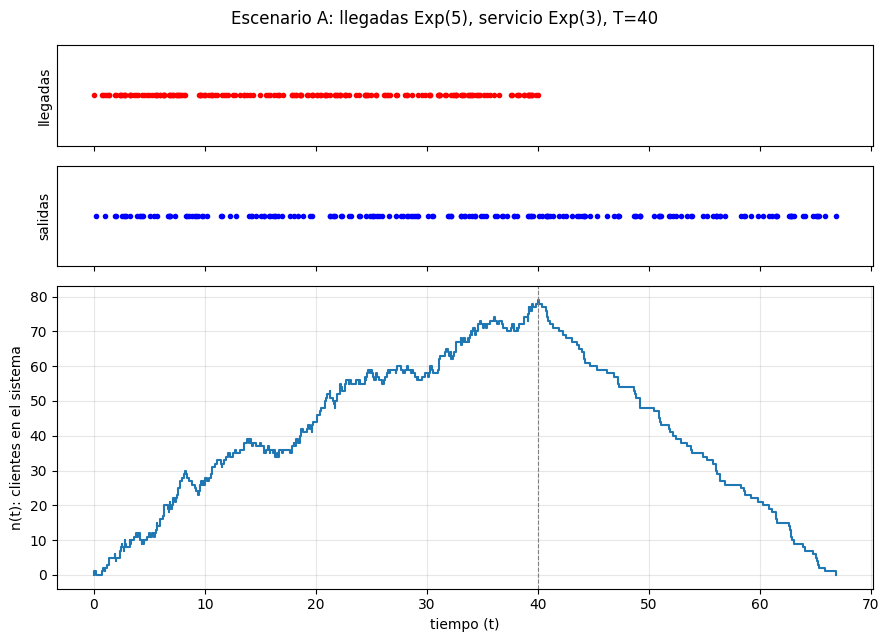

In [3]:
T = 40.0
gA_X, gA_Y = GLC(434287492), GLC(5187324426)
resA = simular_gg1(T, lambda: exponencial(gA_X, 5), lambda: exponencial(gA_Y, 3))
imprimir(resA, 'Escenario A (Exp(5) / Exp(3))')
graficar(resA, 'Escenario A: llegadas Exp(5), servicio Exp(3), T=40', 'gg1_escenarioA.png')

### Escenario B — una ejecución
Llegadas Exp($\lambda=1$) y servicio N($\mu=2,\sigma=1$) truncada en cero.

--- Escenario B (Exp(1) / N(2,1) truncada) ---
Tiempo medio de los clientes en el sistema: 19.4715
Tiempo medio de los clientes en la cola: 17.4254
Tiempo desde T hasta que sale el último cliente (Tp): 34.2618
Número máximo de clientes en el sistema: 18
Total de clientes que pasaron por el sistema: 36


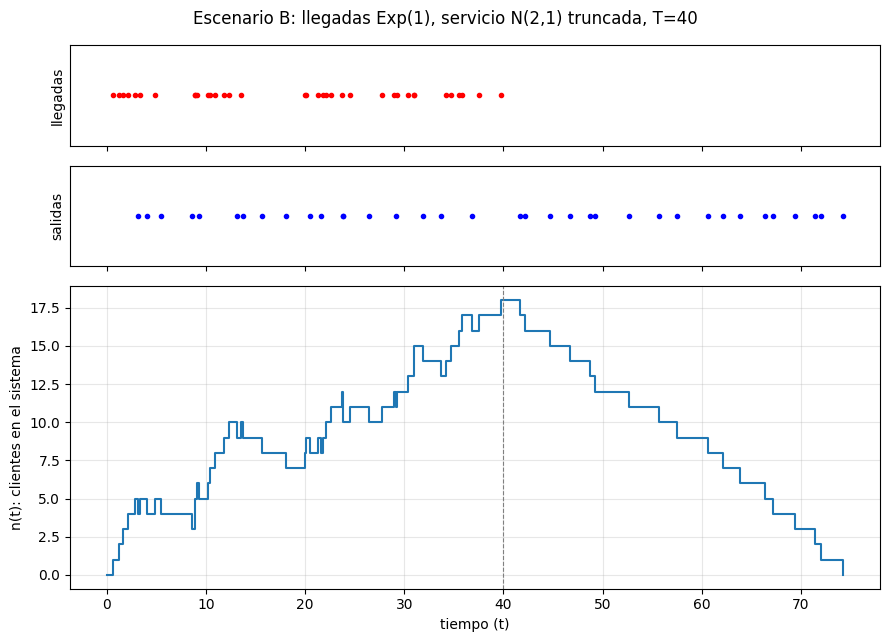

In [4]:
gB_X, gB_Y = GLC(734287493), GLC(9187324427)
resB = simular_gg1(T, lambda: exponencial(gB_X, 1), lambda: normal_truncada(gB_Y, 2, 1))
imprimir(resB, 'Escenario B (Exp(1) / N(2,1) truncada)')
graficar(resB, 'Escenario B: llegadas Exp(1), servicio N(2,1) truncada, T=40', 'gg1_escenarioB.png')

### 10 repeticiones de cada escenario (Tabla 1)
Cada repetición usa semillas distintas para los dos flujos. Se reportan el promedio y la desviación
estándar muestral ($n-1$) de las cinco medidas de desempeño.

In [5]:
def repetir(n_rep, fabrica, semilla_base):
    filas = []
    for r in range(n_rep):
        gX, gY = GLC(semilla_base + 7919 * r), GLC(semilla_base + 104729 * r + 1)
        res = fabrica(gX, gY)
        filas.append([res[k] for k in NOMBRES])
    return np.array(filas, dtype=float)

repA = repetir(10, lambda gX, gY: simular_gg1(T, lambda: exponencial(gX, 5), lambda: exponencial(gY, 3)), 2391)
repB = repetir(10, lambda gX, gY: simular_gg1(T, lambda: exponencial(gX, 1), lambda: normal_truncada(gY, 2, 1)), 6151)

print("Repeticiones escenario A (filas = corridas; columnas = medidas):")
print(np.round(repA, 4))
print("\nRepeticiones escenario B:")
print(np.round(repB, 4))

print("\nTabla 1. Medidas de desempeño luego de 10 simulaciones (promedio +/- desv. estándar)")
print(f"{'Medida de desempeño':60s} {'Escenario A':>22s} {'Escenario B':>22s}")
for j, (k, nombre) in enumerate(NOMBRES.items()):
    a = f"{repA[:, j].mean():.3f} +/- {repA[:, j].std(ddof=1):.3f}"
    b = f"{repB[:, j].mean():.3f} +/- {repB[:, j].std(ddof=1):.3f}"
    print(f"{nombre:60s} {a:>22s} {b:>22s}")

Repeticiones escenario A (filas = corridas; columnas = medidas):
[[ 13.9348  13.6119  24.87    78.     200.    ]
 [ 10.639   10.3219  19.9544  62.     185.    ]
 [  9.5977   9.2816  22.1475  74.     196.    ]
 [ 11.1162  10.7943  20.2     67.     186.    ]
 [ 11.6533  11.3522  17.8167  65.     192.    ]
 [ 19.6031  19.2353  39.5497 115.     215.    ]
 [ 10.4954  10.2038  19.0841  68.     200.    ]
 [ 15.1927  14.8517  26.1778  80.     194.    ]
 [ 11.7276  11.416   25.5547  87.     209.    ]
 [ 13.6064  13.2807  27.0146  84.     204.    ]]

Repeticiones escenario B:
[[28.6406 26.4892 55.4587 27.     44.    ]
 [22.9792 21.1628 45.6712 25.     47.    ]
 [19.7007 17.4676 41.7362 19.     35.    ]
 [21.2349 19.0761 34.5351 18.     34.    ]
 [28.048  25.8397 53.2406 24.     42.    ]
 [23.1483 21.2032 37.8795 21.     39.    ]
 [23.6122 21.5427 42.3573 21.     39.    ]
 [21.9375 20.1736 34.9856 23.     41.    ]
 [19.315  17.3995 35.0556 21.     39.    ]
 [29.8578 27.5842 58.9575 27.     41.   

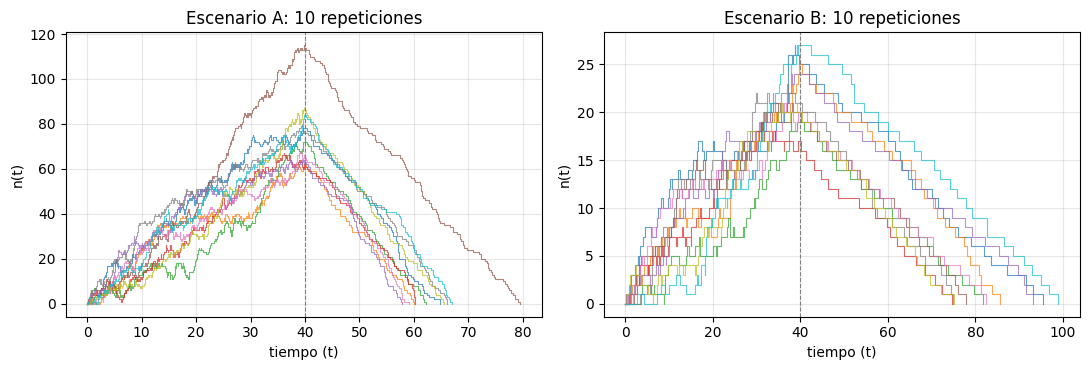

Uniformes consumidas en la corrida única del escenario A: 393
Uniformes consumidas en la corrida única del escenario B: 79


In [6]:
# Figura comparativa de la trayectoria n(t) en las 10 repeticiones de cada escenario
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
for r in range(10):
    gX, gY = GLC(2391 + 7919 * r), GLC(2391 + 104729 * r + 1)
    res = simular_gg1(T, lambda: exponencial(gX, 5), lambda: exponencial(gY, 3))
    ax[0].step(res['at'], res['an'], where='post', lw=0.8, alpha=0.7)
    gX, gY = GLC(6151 + 7919 * r), GLC(6151 + 104729 * r + 1)
    res = simular_gg1(T, lambda: exponencial(gX, 1), lambda: normal_truncada(gY, 2, 1))
    ax[1].step(res['at'], res['an'], where='post', lw=0.8, alpha=0.7)
ax[0].set_title('Escenario A: 10 repeticiones'); ax[1].set_title('Escenario B: 10 repeticiones')
for a in ax:
    a.set_xlabel('tiempo (t)'); a.set_ylabel('n(t)'); a.axvline(T, color='gray', ls='--', lw=0.8); a.grid(alpha=0.3)
fig.tight_layout(); fig.savefig('gg1_repeticiones.png', dpi=150, bbox_inches='tight'); plt.show()

print("Uniformes consumidas en la corrida única del escenario A:", gA_X.consumidos + gA_Y.consumidos)
print("Uniformes consumidas en la corrida única del escenario B:", gB_X.consumidos + gB_Y.consumidos)